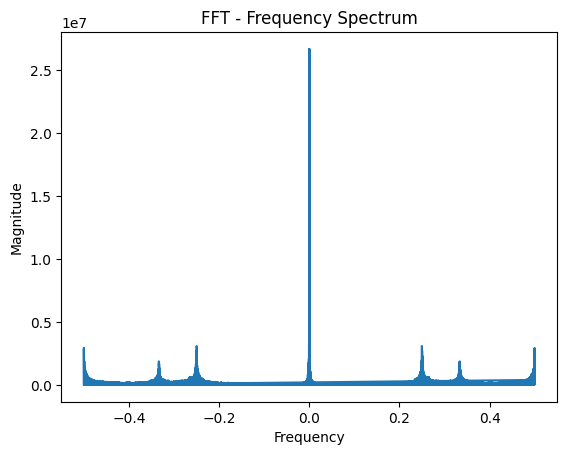

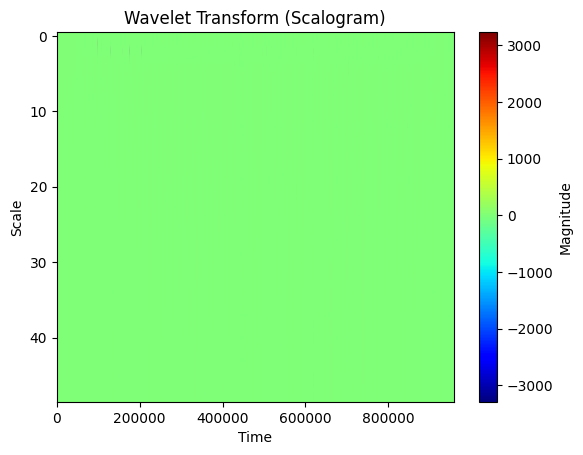

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
import pywt

# Load dataset
df = pd.read_csv("../data/indoorAir.csv")

# Example: use CO2 column (change if needed)
signal = df["scd41_co2"].dropna().values
signal = signal - np.mean(signal)  # remove DC component
# -------------------------
# 1. Fourier Transform (FFT)
# -------------------------
fft_values = fft(signal)
freq = np.fft.fftfreq(len(signal))

plt.figure()
plt.plot(freq, np.abs(fft_values))
plt.title("FFT - Frequency Spectrum")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()

# -------------------------
# 2. Wavelet Transform
# -------------------------
coeffs, freqs = pywt.cwt(signal, scales=np.arange(1, 50), wavelet='morl')

plt.figure()
plt.imshow(coeffs, aspect='auto', cmap='jet')
plt.title("Wavelet Transform (Scalogram)")
plt.xlabel("Time")
plt.ylabel("Scale")
plt.colorbar(label="Magnitude")
plt.show()